### Approach 4: HOG-based Patch Classification

This approach represents image patches using Histogram of Oriented Gradients (HOG),
which captures local edge orientations and texture information. Each patch is
classified as floor or non-floor using an SVM.

HOG features focus on shape and structure rather than raw color, making them
effective for texture-based recognition. However, this approach requires sufficient
training data to generalize well.

**Feature Vector:** HOG descriptor  
**Sample Unit:** Patch  
**Strengths:** Captures texture and local structure  
**Limitations:** Ignores color information, prone to overfitting with limited data  
**Expected Behavior:** High training accuracy but sensitive to dataset size

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from pycocotools.coco import COCO
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# IMAGE_DIR = "/content/drive/MyDrive/Floor Segmentation.v4i.coco-segmentation/train"
# COCO_JSON = "/content/drive/MyDrive/Floor Segmentation.v4i.coco-segmentation/train/_annotations.coco.json"
IMAGE_DIR = "/content/drive/MyDrive/230077_vivekananda"
COCO_JSON = "/content/drive/MyDrive/230077_vivekananda/vivekananda.json"

coco = COCO(COCO_JSON)

print(f"Total images: {len(coco.imgs)}")
print(f"Total annotations: {len(coco.getAnnIds())}")

# Floor category IDs (adjust if needed)
FLOOR_CAT_IDS = [0, 1]

loading annotations into memory...
Done (t=0.72s)
creating index...
index created!
Total images: 10
Total annotations: 10


In [4]:
img_ids = list(coco.imgs.keys())
print(f"Images to process: {len(img_ids)}")

Images to process: 10


In [5]:
PATCH_SIZE = 64

X = []
y = []

print("Extracting HOG patches...")

for i, img_id in enumerate(img_ids):
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(IMAGE_DIR, img_info["file_name"])
    img = cv2.imread(img_path)

    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    floor_mask = np.zeros((h, w), dtype=np.uint8)
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    for ann in anns:
        if ann["category_id"] in FLOOR_CAT_IDS:
            floor_mask |= coco.annToMask(ann)

    for _ in range(20):
        py = np.random.randint(0, h - PATCH_SIZE)
        px = np.random.randint(0, w - PATCH_SIZE)

        patch = gray[py:py+PATCH_SIZE, px:px+PATCH_SIZE]
        mask_patch = floor_mask[py:py+PATCH_SIZE, px:px+PATCH_SIZE]

        label = 1 if np.mean(mask_patch) > 0.5 else 0

        fd = hog(
            patch,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys"
        )

        X.append(fd)
        y.append(label)

    if (i + 1) % 50 == 0:
        print(f"Processed {i+1}/{len(img_ids)} images")

X = np.array(X)
y = np.array(y)

print("Total samples:", len(X))
print("Floor patches:", np.sum(y == 1))
print("Non-floor patches:", np.sum(y == 0))

Extracting HOG patches...
Total samples: 200
Floor patches: 97
Non-floor patches: 103


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train patches:", len(X_train))
print("Test patches:", len(X_test))

Train patches: 160
Test patches: 40


In [22]:
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

svm.fit(X_train, y_train)

SVC(random_state=42)

In [23]:
y_pred = svm.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Train Accuracy:", svm.score(X_train, y_train))
print("Test Accuracy:", svm.score(X_test, y_test))

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.90      0.76        21
           1       0.82      0.47      0.60        19

    accuracy                           0.70        40
   macro avg       0.74      0.69      0.68        40
weighted avg       0.73      0.70      0.68        40

Train Accuracy: 0.98125
Test Accuracy: 0.7


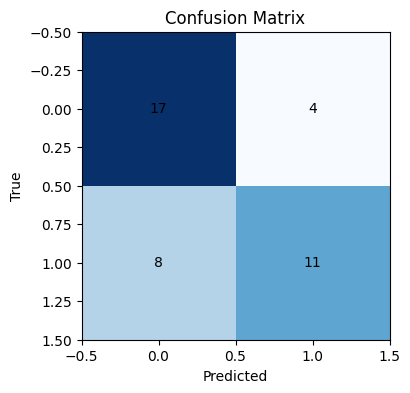

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [11]:
def predict_floor_hog(img_path, svm, scaler, patch_size=64, stride=16):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    prob_map = np.zeros((h, w), dtype=np.float32)
    count_map = np.zeros((h, w), dtype=np.float32)

    for y0 in range(0, h - patch_size, stride):
        for x0 in range(0, w - patch_size, stride):
            patch = gray[y0:y0+patch_size, x0:x0+patch_size]

            fd = hog(
                patch,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                block_norm="L2-Hys"
            )

            fd = scaler.transform([fd])
            pred = svm.predict(fd)[0]

            prob_map[y0:y0+patch_size, x0:x0+patch_size] += pred
            count_map[y0:y0+patch_size, x0:x0+patch_size] += 1

    mask = (prob_map / (count_map + 1e-6)) > 0.5
    return img, mask.astype(np.uint8)

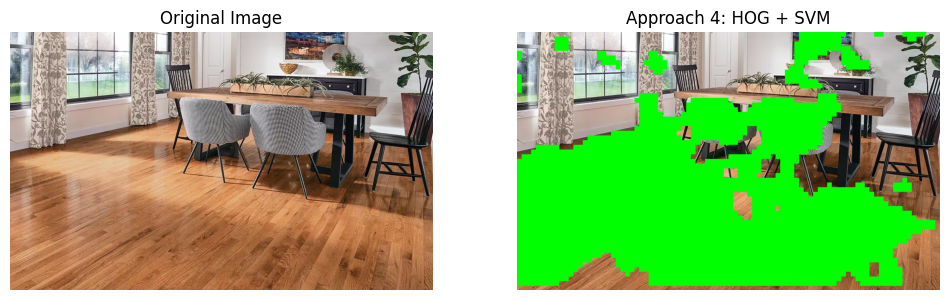

In [14]:
test_img_path = "/content/floor-1.avif"

img, mask = predict_floor_hog(test_img_path, svm, scaler)

overlay = img.copy()
overlay[mask == 1] = [0, 255, 0]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Approach 4: HOG + SVM")
plt.axis("off")

plt.show()

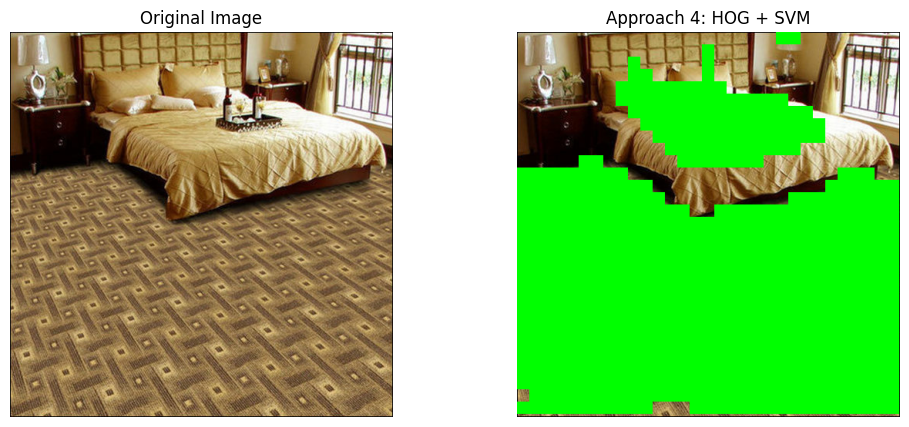

In [15]:
test_img_path = "/content/floor-10.jpg"

img, mask = predict_floor_hog(test_img_path, svm, scaler)

overlay = img.copy()
overlay[mask == 1] = [0, 255, 0]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Approach 4: HOG + SVM")
plt.axis("off")

plt.show()